# Figure 2: splice and 5' UTR score distributions

**Purpose.** Show how pooling splice and 5' UTR variants inflates the apparent separation of Evo 2 7B scores.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/processed/clinvar_benchmark_updated.csv` (the full scored benchmark; not stored in GitHub).
- **Outputs:** `results/tables/figure_2_score_distributions_auroc.csv` and `results/figures/figure_2.svg`.
- **Randomness:** none.
- **Compute:** CPU; no model inference is performed.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")


FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and prepare input


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

sns.set(style="white", font_scale=1.2)
data = pd.read_csv(
    SCORED_BENCHMARK_PATH,
    low_memory=False,
    dtype={"#CHROM": str},
)


def get_group(row):
    if row["group: 5'UTR"] == 1:
        return "5'UTR"
    if row["group: splice"] == 1:
        return "Splice"
    return "Other"


data["group"] = data.apply(get_group, axis=1)
data = data[data["group"].isin(["5'UTR", "Splice"])].copy()
data["label_str"] = data["ClinVar_label"].map(
    {0: "Benign variants", 1: "Pathogenic variants"}
)
pooled = data.copy()
pooled["group_plot"] = "Union of splice and 5'UTR"


## 3. Compute the reported AUROCs


In [3]:
rows = []
for label, subset in {
    "Splice": data[data["group"] == "Splice"],
    "5' UTR": data[data["group"] == "5'UTR"],
    "Pooled": data,
}.items():
    complete = subset.dropna(subset=["ClinVar_label", "Evo2_7B"])
    score = 1 - roc_auc_score(complete["ClinVar_label"], complete["Evo2_7B"])
    rows.append({"group": label, "n": len(complete), "auroc": score})

auroc_table = pd.DataFrame(rows)
auroc_table.to_csv(
    TABLE_DIR / "figure_2_score_distributions_auroc.csv",
    index=False,
)
display(auroc_table)


,group,n,auroc
0,Splice,10174,0.713641
1,5' UTR,2386,0.808312
2,Pooled,12560,0.976787


## 4. Render the manuscript figure


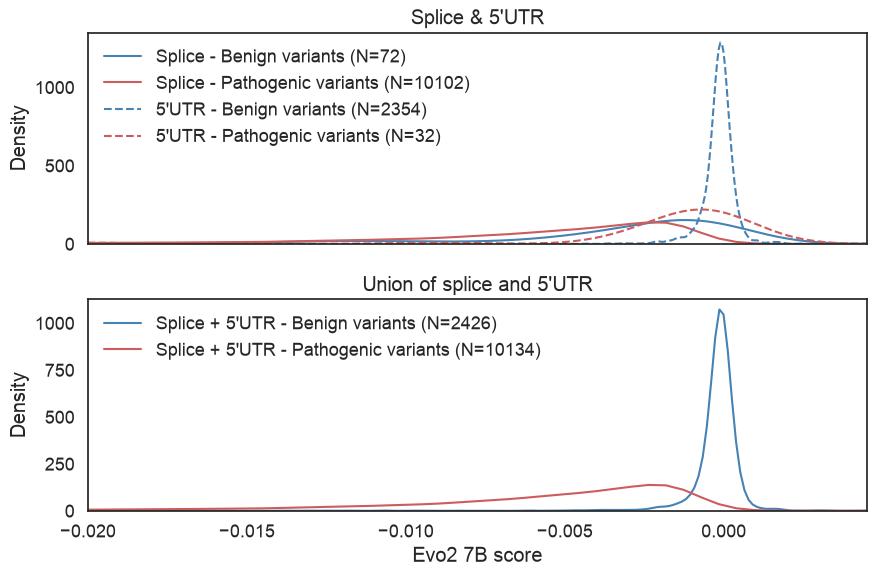

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

palette = {"Benign variants": "steelblue", "Pathogenic variants": "indianred"}
linestyles = {"Splice": "-", "5'UTR": "--"}

axis = axes[0]
for group in ["Splice", "5'UTR"]:
    for label in ["Benign variants", "Pathogenic variants"]:
        subset = data[(data["group"] == group) & (data["label_str"] == label)]
        if len(subset) > 1:
            sns.kdeplot(
                data=subset,
                x="Evo2_7B",
                fill=False,
                ax=axis,
                label=f"{group} - {label} (N={len(subset)})",
                color=palette[label],
                linestyle=linestyles[group],
                bw_adjust=0.8,
                common_norm=False,
            )
axis.set_title("Splice & 5'UTR")
axis.set_ylabel("Density")
axis.set_xlabel("")
axis.legend(loc="upper left", frameon=False)

axis = axes[1]
for label in ["Benign variants", "Pathogenic variants"]:
    subset = pooled[pooled["label_str"] == label]
    if len(subset) > 1:
        sns.kdeplot(
            data=subset,
            x="Evo2_7B",
            fill=False,
            ax=axis,
            label=f"Splice + 5'UTR - {label} (N={len(subset)})",
            color=palette[label],
            bw_adjust=0.8,
        )
axis.set_title("Union of splice and 5'UTR")
axis.set_ylabel("Density")
axis.set_xlabel("Evo2 7B score")
axis.legend(loc="upper left", frameon=False)

for axis in axes:
    axis.set_xlim(-0.02, 0.0045)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_2.svg", format="svg", bbox_inches="tight")
plt.show()


## 5. Validate outputs


In [5]:

validate_output_files([
    TABLE_DIR / "figure_2_score_distributions_auroc.csv",
    FIGURE_DIR / "figure_2.svg",
])


Validated 2 output file(s).
